In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Try using a semicolon (;) as the delimiter
df = pd.read_csv('C:/Users/bania/Desktop/data analytics/Python/Projects/dataset/final_gold_data.csv', sep=';', engine='python')
print(df.head())
print(df.tail())

#print(df.info())


    timestamp   open   high    low  close  volume currency   unit  \
0  2000-08-30  273.9  273.9  273.9  273.9       0      usd  ounce   
1  2000-08-31  274.8  278.3  274.8  278.3       0      usd  ounce   
2  2000-09-01  277.0  277.0  277.0  277.0       0      usd  ounce   
3  2000-09-05  275.8  275.8  275.8  275.8       2      usd  ounce   
4  2000-09-06  274.2  274.2  274.2  274.2       0      usd  ounce   

                                           headlines  
0  Recalls Fuel Disclosure Debate / Deutsche Tele...  
1  Credit Suisse's Wheat Faces Deal / Regulators ...  
2  Nordstrom's Chief Resigns / Judge Dismisses Ca...  
3  Market Pace Slows After 10-Year Run / Clickman...  
4  France Telecom Profit Increases / Locale-Based...  
       timestamp    open    high     low   close  volume currency   unit  \
6172  2025-04-08  2994.0  3014.5  2968.4  2968.4    3213      usd  ounce   
6173  2025-04-09  2965.8  3090.4  2965.8  3056.5    2175      usd  ounce   
6174  2025-04-10  3073.9  3

In [2]:
#starts by fixing data type
df['timestamp']=pd.to_datetime(df['timestamp'])
df['currency']=df['currency'].str.strip().str.lower()
df['headlines']=df['headlines'].str.lower()
#df=df.drop(['unit'],axis=1,inplace=True)  #Dropped unit as it is not needed
print(df.info())
#print(df.head)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6177 entries, 0 to 6176
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  6177 non-null   datetime64[ns]
 1   open       6177 non-null   float64       
 2   high       6177 non-null   float64       
 3   low        6177 non-null   float64       
 4   close      6177 non-null   float64       
 5   volume     6177 non-null   int64         
 6   currency   6177 non-null   object        
 7   unit       6177 non-null   object        
 8   headlines  6177 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 434.4+ KB
None


In [3]:
#Checking duplicates or nan value
print(df.duplicated().sum())
print(df.isnull().sum())

0
timestamp    0
open         0
high         0
low          0
close        0
volume       0
currency     0
unit         0
headlines    0
dtype: int64


# What is the average closing price of gold over time?

In [4]:
print(df['close'].mean())

1181.0123037073013


# Which day had the highest closing price? The lowest?

In [5]:
print("Day having Highest closing value:",df['timestamp'][df['close'].idxmax()])
print("Day having lowest closinng value:",df['timestamp'][df['close'].idxmin()])


Day having Highest closing value: 2025-04-11 00:00:00
Day having lowest closinng value: 2001-02-15 00:00:00


# What is the average daily price range (high - low)?

In [6]:
df['range']=df['high']-df['low']
print("The average daily price range is",df['range'].mean())

The average daily price range is 12.068301764610654


# How does the gold price fluctuate over months or years?

In [7]:
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df.groupby('year')['close'].mean()
df.groupby(['year', 'month'])['close'].mean()

year  month
2000  8         276.100000
      9         273.390000
      10        269.809091
      11        265.875000
      12        271.515000
                  ...     
2024  12       2643.580952
2025  1        2722.947619
      2        2897.115789
      3        2986.409524
      4        3092.620000
Name: close, Length: 297, dtype: float64

# What are the most volatile periods (highest daily changes)?

In [8]:
df['daily_change']=df['close'].diff().abs()
most_volatile=df.nlargest(10,'daily_change')[['timestamp','close','daily_change']]
print(most_volatile)

      timestamp   close  daily_change
3159 2013-04-15  1360.6         140.4
2749 2011-08-24  1754.1         104.2
2770 2011-09-23  1637.5         101.7
6174 2025-04-10  3155.2          98.7
5064 2020-11-09  1853.2          97.1
4904 2020-03-24  1660.2          93.2
6081 2024-11-25  2616.8          93.1
5001 2020-08-11  1932.6          91.8
6173 2025-04-09  3056.5          88.1
3206 2013-06-20  1285.9          87.7


# Is there a long-term trend (upward/downward) in gold prices?

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


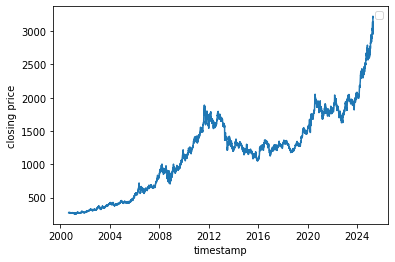

In [ ]:
x=df['timestamp']
y=df['close']
plt.plot(x,y)
plt.xlabel("timestamp")
plt.ylabel("closing price")
plt.show()